# Import the necessary libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.model_selection import train_test_split

# Import the dataset

### Brief Summary of Dataset

This dataset contains observations about income (in a range of `$15k` to `$75k`) and happiness (rated on a scale of 1 to 10) in an imaginary sample of 500 people. The income values are divided by 10,000 to make the income data match the scale of the happiness scores (so a value of `$2` represents `$20,000`, `$3` is `$30,000`, etc.)

In [2]:
df = pd.read_csv("test_datasets/income.data.csv", index_col=0)

df.head(5)

,income,happiness
1,3.862647,2.314489
2,4.979381,3.433490
3,4.923957,4.599373
4,3.214372,2.791114
5,7.196409,5.596398


In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
income,498.0,4.466902,1.737527,1.506275,3.006256,4.423710,5.991913,7.481521
happiness,498.0,3.392859,1.432813,0.266044,2.265864,3.472536,4.502621,6.863388


In [4]:
df.isnull().sum().sum()

np.int64(0)

From our above exploration, we can confirm that there are no null values, the standard deviation is large(CV is above 20% for both features) and the values are well spread out around the mean since the mean is close to the median(50th quartile) and the min and max values are well spread around the mean. The dataset is okay to move on to the next phase.

# Check for Linearity

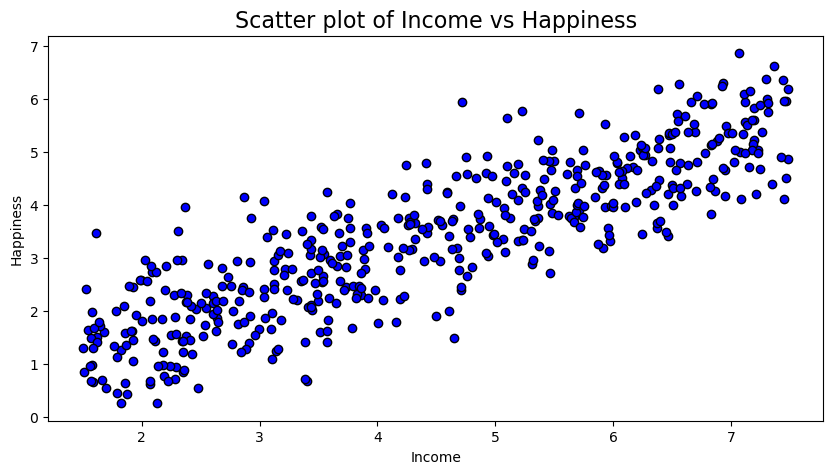

In [5]:
plt.figure(figsize=(10,5))
plt.scatter(df["income"], df["happiness"], color='blue', edgecolor='k')
plt.xlabel("Income")
plt.ylabel("Happiness")
plt.title("Scatter plot of Income vs Happiness", fontsize=16)

plt.show()

From the above plot, we can visually confirm that there is a linear relationship between the level of income and happiness of an individual in the imaginary sample. This showsthat we can fit a linear regression model into our dataset to capture the intricate relationship between the features.

# Fitting our Model using Sklearn

We are checking if the happiness of an individual in the imaginary dataset is equivalent to the individual's income.

In [9]:
X = df["income"].values
y = df["happiness"].values

X_reshaped = X.reshape(-1,1)

model = LinearRegression()
model.fit(X_reshaped, y)

y_pred = model.predict(X_reshaped)

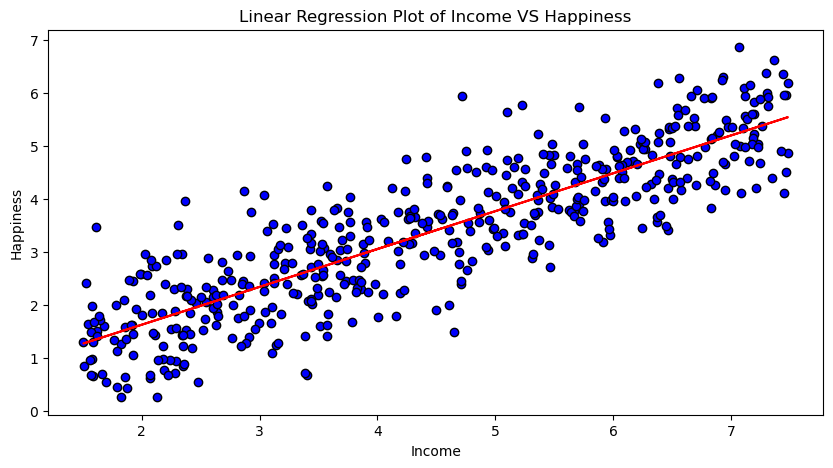

In [10]:
plt.figure(figsize=(10,5))
plt.scatter(X, y, color='blue', edgecolor='k')
plt.plot(X, y_pred, color='red')
plt.title("Linear Regression Plot of Income VS Happiness")
plt.xlabel("Income")
plt.ylabel("Happiness")

plt.show()

# Assessing the Model's Accuracy

In [27]:
print("Slope:", round(model.coef_[0], 4))
print("Intercept:", round(model.intercept_, 4))

print("RSS:", round(sum((y - y_pred)**2), 4))
print("R2 Score:", round(metrics.r2_score(y, y_pred), 4))
print("MAE:", round(metrics.mean_absolute_error(y, y_pred), 4))
print("MSE:", round(metrics.mean_squared_error(y, y_pred), 4))
print("RMSE:", round(np.sqrt(metrics.mean_squared_error(y, y_pred)), 4))

Slope: 0.7138
Intercept: 0.2043
RSS: 255.7715
R2 Score: 0.7493
MAE: 0.5746
MSE: 0.5136
RMSE: 0.7167


The model looks like it fits the data well. R2 explains the variance of 75% of the data, MAE, MSE and RMSE values are relatively small. But we cannot be too sure. Lets do a train-test-split to see how our model will behave when fitted with unseen data.

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X_reshaped, y, test_size=0.2, random_state=40)

model_2 = LinearRegression()
model_2.fit(X_train, y_train)

LinearRegression()

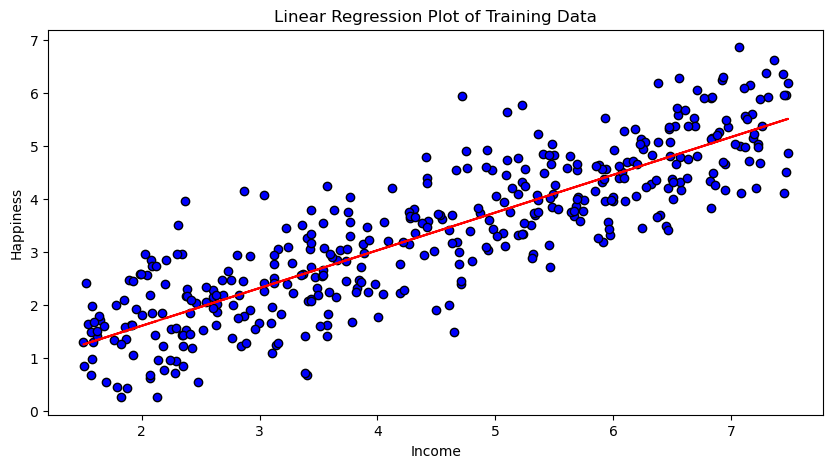

In [31]:
y_pred = model_2.predict(X_train)

plt.figure(figsize=(10,5))
plt.scatter(X_train, y_train, color='blue', edgecolor='k')
plt.plot(X_train, y_pred, color='red')
plt.title("Linear Regression Plot of Training Data")
plt.xlabel("Income")
plt.ylabel("Happiness")

plt.show()

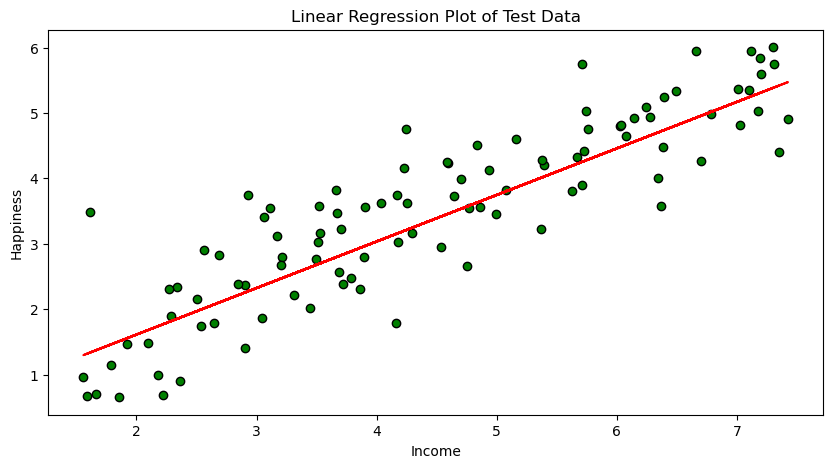

In [33]:
y_pred_test = model_2.predict(X_test)

plt.figure(figsize=(10,5))
plt.scatter(X_test, y_test, color='green', edgecolor='k')
plt.plot(X_test, y_pred_test, color='red')
plt.title("Linear Regression Plot of Test Data")
plt.xlabel("Income")
plt.ylabel("Happiness")

plt.show()

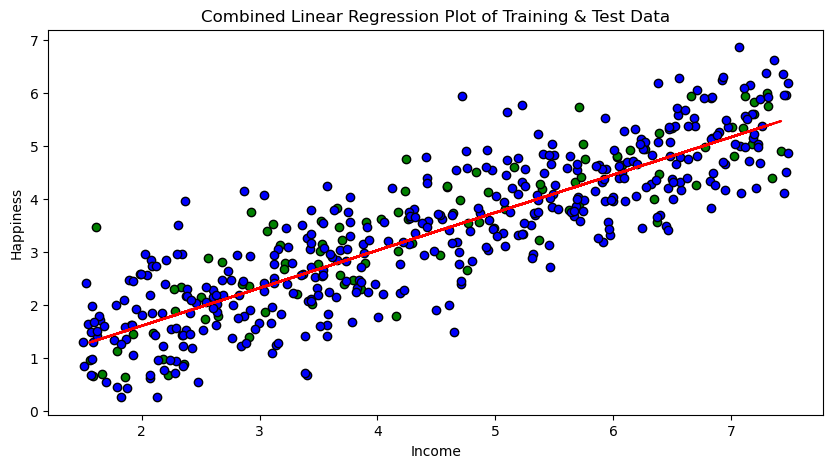

In [37]:
plt.figure(figsize=(10,5))
plt.scatter(X_test, y_test, color='green', edgecolor='k')
plt.scatter(X_train, y_train, color='blue', edgecolor='k')
plt.plot(X_test, y_pred_test, color='red')
# plt.plot(X_train, y_pred, color='orange')
plt.title("Combined Linear Regression Plot of Training & Test Data")
plt.xlabel("Income")
plt.ylabel("Happiness")

plt.show()

In [44]:
print("Slope Train:", round(model_2.coef_[0], 4))
print("Intercept Train:", round(model_2.intercept_, 4))

Slope Train: 0.7116
Intercept Train: 0.1886


In [43]:
print("RSS Train:", round(sum((y_train - y_pred)**2), 4))
print("R2 Score Train:", round(metrics.r2_score(y_train, y_pred), 4))
print("MAE Train:", round(metrics.mean_absolute_error(y_train, y_pred), 4))
print("MSE Train:", round(metrics.mean_squared_error(y_train, y_pred), 4))
print("RMSE Train:", round(np.sqrt(metrics.mean_squared_error(y_train, y_pred)), 4))

RSS Train: 212.5297
R2 Score Train: 0.7433
MAE Train: 0.5849
MSE Train: 0.534
RMSE Train: 0.7307


In [42]:
print("RSS Test:", round(sum((y_test - y_pred_test)**2), 4))
print("R2 Score Test:", round(metrics.r2_score(y_test, y_pred_test), 4))
print("MAE Test:", round(metrics.mean_absolute_error(y_test, y_pred_test), 4))
print("MSE Test:", round(metrics.mean_squared_error(y_test, y_pred_test), 4))
print("RMSE Test:", round(np.sqrt(metrics.mean_squared_error(y_test, y_pred_test)), 4))

RSS Test: 43.573
R2 Score Test: 0.772
MAE Test: 0.5376
MSE Test: 0.4357
RMSE Test: 0.6601
